# Домашнее задание 2. Микросервисная архитектура
Студент: *Вольхин Сергей Александрович*, P2, 05.04.2026

Это задание выполняется в рамках модуля 2 «Микросервисная архитектура». Вы закрепите навыки разделения монолита на микросервисы.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [ ]:
%%capture
!sudo apt install graphviz
!pip install diagrams docker-compose-diagram
!pip install fastapi uvicorn[standard] -qq
!pip install --upgrade sqlalchemy

### Задание 1. Сравнить монолитную и микросервисную архитектуру: преимущества и недостатки

В каком случае вы не будете разбивать монолит на микросервисы и почему?

В каком случае монолит обязательно разбивать на микросервисы и почему?

На работе я каждый день имею дело с MySQL-монолитом, где бизнес-логика размазана по хранимым процедурам. Когда мне нужно поменять одну процедуру, я вынужден прогонять регресс-тесты на всём, потому что зависимости между процедурами не всегда очевидны. Деплой через Liquibase - одна миграция, и если что-то пошло не так, откатывать приходится всю цепочку. Это классическая боль монолита: всё связано со всем.

При этом монолит - не зло. Он хорош, когда команда маленькая и продукт только стартует. Два-три разработчика, общая кодовая база - это плюс: не надо думать про сетевые вызовы между сервисами, eventual consistency, распределённые транзакции. Деплоить один артефакт проще, чем оркестрировать десяток. Мониторинг тривиальный - один процесс, один лог. Насколько я понял из лекций, это ровно то, что рекомендует Мартин Фаулер: начинай с монолита, разбивай когда станет больно.

У микросервисов свои проблемы, и серьёзные. Сетевые вызовы вместо вызова метода в памяти- это latency, retry-логика, circuit breakers. Отладка распределённых транзакций - отдельная боль: вместо одного ROLLBACK в MySQL приходится городить саги или компенсирующие транзакции. CI/CD пайплайн на каждый сервис, свой мониторинг, свои логи - операционный overhead растёт кратно числу сервисов. На моей практике даже три сервиса с общим RabbitMQ требуют больше DevOps-внимания, чем один монолит.

Монолит нужно разбивать, когда команда выросла и разные группы начинают друг другу мешать. Четыре отдела коммитят в один репозиторий - мерж-конфликты каждый день, релизный цикл растягивается, потому что ждём пока все дотестируют свои фичи. Второй случай - неравномерная нагрузка: один модуль жрёт 80% CPU, остальные простаивают. Горизонтально масштабировать монолит целиком - дорого и неэффективно. Третий - технологическая гибкость: один сервис лучше написать на Go ради перформанса, другой на Python ради ML-библиотек.

В своём пет-проекте на FastAPI + PostgreSQL + pgvector я по сути уже делаю микросервис - отдельный API, отдельная база, чётко определённый контракт. Честно говоря, для маленького проекта это работает, потому что сервис один. Если бы их было десять и все общались по сети - я бы потратил больше времени на инфраструктуру, чем на бизнес-логику.

Итого: не буду разбивать монолит, если проект на ранней стадии (границы доменов не ясны), команда маленькая, и нет реальных проблем с масштабируемостью. Классическая ошибка - разбивать ради разбивания, потому что так модно. Буду разбивать, если команды блокируют друг друга на деплое, нагрузка на модули неравномерная, или нужна независимая масштабируемость компонентов.

### Задание 2. Разбить монолит на микросервисы

Есть монолитное веб-приложение. Четыре отдела генерируют нагрузку по 100 RPS каждый (суммарно ≈400 RPS), а текущая пропускная способность веб-сервера — ≈200 RPS; начинает ощущаться деградация. Для упрощения считаем, что сеть не узкое место, ресурсов RAM/CPU/HDD достаточно, техдолг низкий, финансовых ограничений нет.

Задача. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита:
- Как вы диагностируете связность и выбираете границы сервисов (по доменам, бизнес-процессам или данным, допустим комбинированный вариант).
- Какие части вы вынесете первыми, чтобы снять узкое место по RPS, и почему.
- Как будете обеспечивать временную совместную работу старого и нового (этапный переход, strangler pattern).
- Кто владеет данными после разделения и как вы минимизируете риски согласованности.
- Нужен ли API-Gateway на входе и какие задачи он возьмет (маршрутизация, аутентификация, агрегация).



Мой подход к декомпозиции - начинать с доменного анализа, а не с кода. По диаграмме монолита видно, что четыре отдела (логистика, закупки, контроль качества, бухгалтерия) работают через общий веб-сервер с единой базой данных. Каждый отдел генерирует по 100 RPS, суммарно 400 RPS при потолке сервера в 200 RPS. Дольше всего я провозился с границами сервисов - сначала хотел каждую CRUD-операцию в отдельный сервис, потом понял что это оверинжиниринг. Правильная гранулярность - по bounded context, и границы отделов тут хороший ориентир.

Первыми выношу логистику и закупки - они генерируют суммарно 200 RPS и относительно независимы от бухгалтерии. После их вынесения на монолите остаётся 200 RPS (контроль качества + бухгалтерия), что вписывается в его пропускную способность. Это даёт время на спокойную миграцию остальных.

Переход - через Strangler Fig Pattern. Ставлю API Gateway (Nginx) перед монолитом и постепенно перенаправляю трафик на новые сервисы по одному маршруту за раз. Старый монолит продолжает работать, пока не перенесём весь трафик. У нас на работе так же мигрировали MySQL - запускали новый инстанс рядом со старым и переключали таблицы по одной через proxy. Тот же принцип.

Данные - каждый сервис получает свою базу. Логистика и закупки уходят в свои PostgreSQL-инстансы (мне PostgreSQL ближе, плюс у него лучше с JSON-полями для гибких схем). Бухгалтерия с контролем качества пока остаются на legacy MySQL. Согласованность - eventual consistency через события: перевозка оплачена → событие в очередь → бухгалтерия обновляет баланс.

API Gateway на входе - обязателен. Он берёт на себя маршрутизацию (какой запрос куда идёт), аутентификацию (одна точка проверки токенов), rate limiting. Фронт не должен знать, какой запрос идёт в монолит, а какой - в микросервис.

Ниже - диаграмма монолита до и схема промежуточного состояния после вынесения первых двух сервисов:

In [ ]:
%%writefile /content/diagram.py
from diagrams import Cluster, Diagram
from diagrams.onprem.compute import Server
from diagrams.aws.database import RDS
from diagrams.programming.flowchart import Action
from diagrams.onprem.client import Users

with Diagram("monolith", show=False):

    with Cluster("Отделы"):
        depts = [Users("логистика"),
                     Users("закупки"),
                     Users("контроль качества"),
                     Users("бухгалтерия")]

    with Cluster("Монолит, среда развертывания - bare metal"):
      with Cluster("Данные"):
        storage = [RDS("единая база данных")]

      with Cluster("Веб-сервер"):
        webserver = [Server("сервер")]

      with Cluster("Протоколы"):
        protocols = [Action("HTTPS"),
        Action("RPC"),
        Action("HTTP")]

      with Cluster("Формат"):
        formats = [Action("XML"),
        Action("JSON"),
        Action("Текст")]

      with Cluster("Бизнес-процесс"):
        process = [Action("Оплатить перевозку"),
        Action("Оплатить товар"),
        Action("Оплатить инспекцию")]

    storage[0] >> webserver[0]
    webserver[0] >> storage[0]
    storage[0] >> depts[3]
    depts[3] >> storage[0]

    depts[0] >> process[0] >> formats[0] >> protocols[0] >> webserver[0]
    depts[1] >> process[1] >> formats[1] >> protocols[1] >> webserver[0]
    depts[2] >> process[2] >> formats[2] >> protocols[2] >> webserver[0]


Writing /content/diagram.py


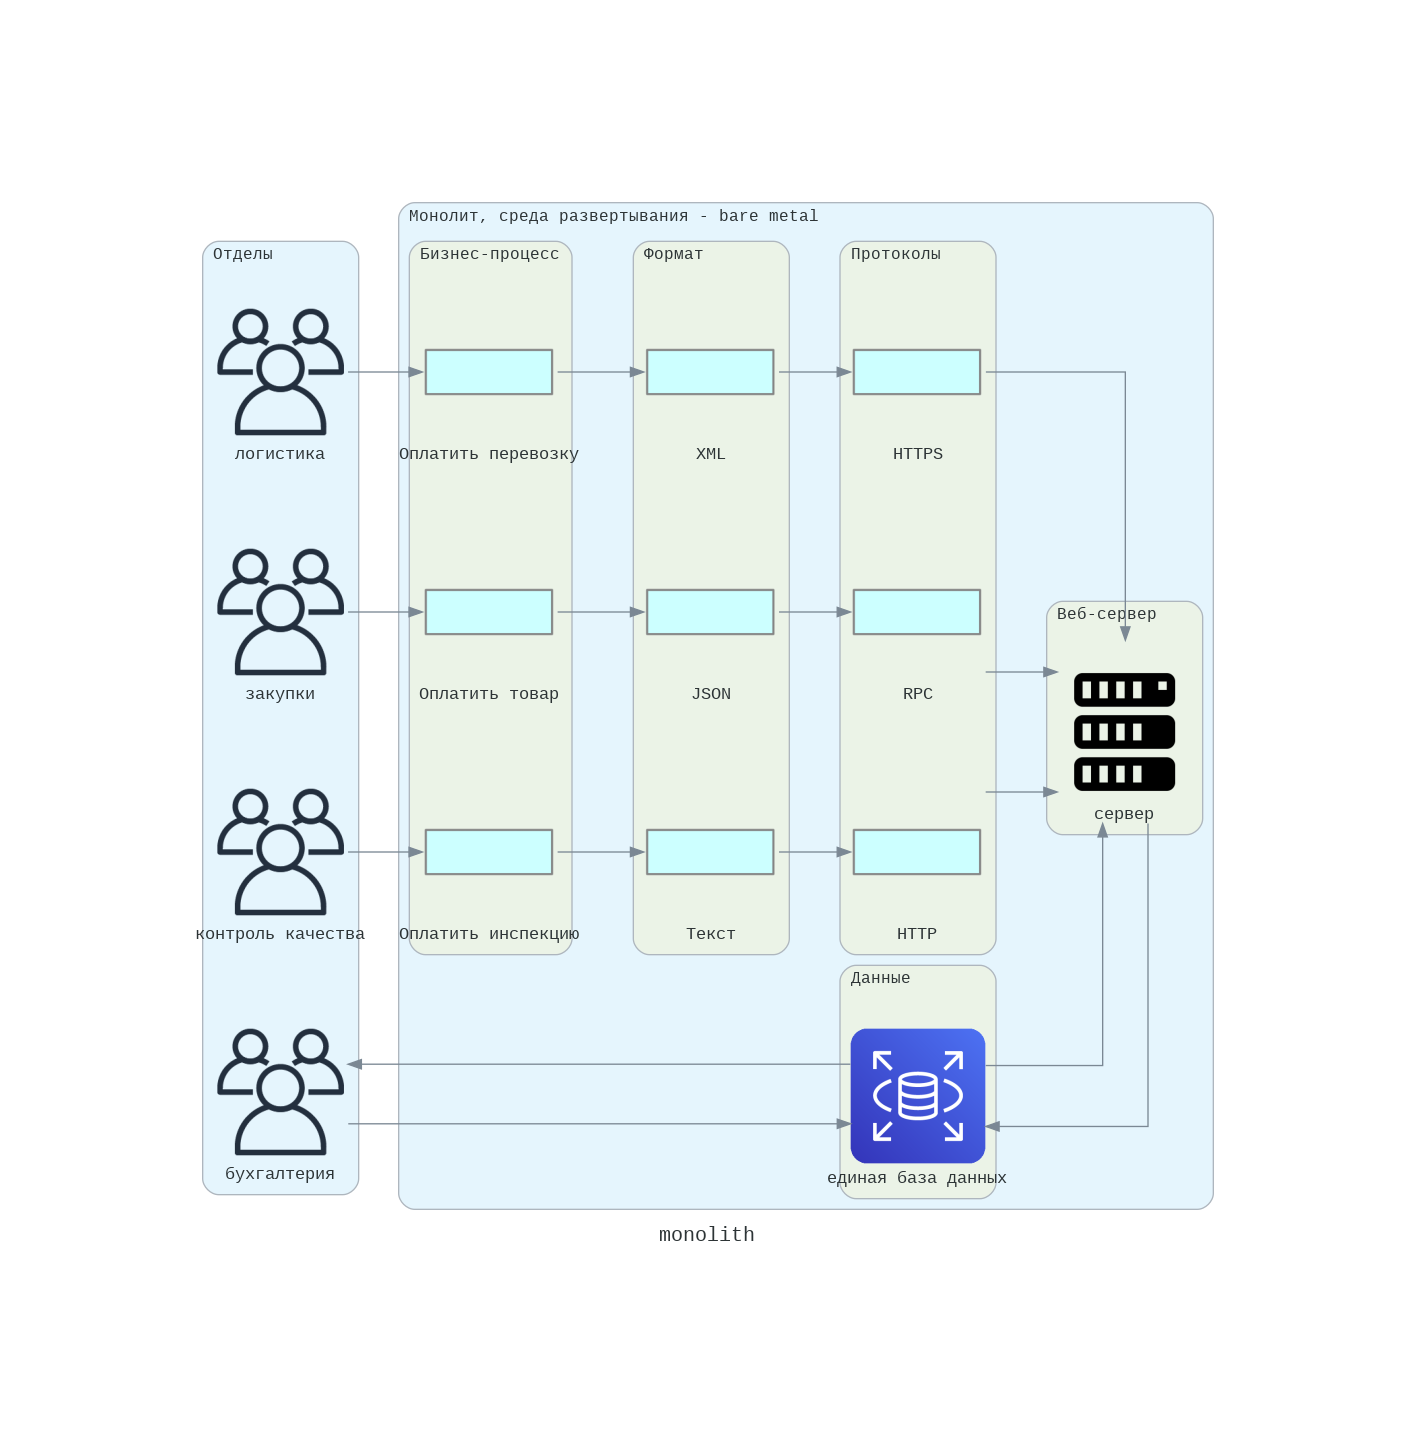

In [ ]:
from IPython.display import Image, display
!python diagram.py
image_path = '/content/monolith.png'
display(Image(filename=image_path))

In [ ]:
%%writefile /content/microservices_diagram.py
from diagrams import Cluster, Diagram, Edge
from diagrams.onprem.compute import Server
from diagrams.onprem.database import PostgreSQL, MySQL
from diagrams.onprem.queue import RabbitMQ
from diagrams.onprem.network import Nginx
from diagrams.onprem.client import Users

graph_attr = {
    "fontsize": "14",
    "nodesep": "1.0",
    "ranksep": "1.2",
    "pad": "0.5",
    "splines": "ortho",
}

with Diagram("microservices", show=False, direction="LR",
             graph_attr=graph_attr):

    with Cluster("Отделы"):
        logistics = Users("Логистика")
        procurement = Users("Закупки")
        qc = Users("Контроль качества")
        accounting = Users("Бухгалтерия")

    gateway = Nginx("API Gateway")

    logistics >> gateway
    procurement >> gateway
    qc >> gateway
    accounting >> gateway

    with Cluster("Микросервисы (200 RPS)"):
        svc_log = Server("Сервис логистики")
        log_db = PostgreSQL("logistics_db")
        svc_proc = Server("Сервис закупок")
        proc_db = PostgreSQL("procurement_db")

    broker = RabbitMQ("Очередь сообщений")

    with Cluster("Монолит (200 RPS)"):
        monolith = Server("КК + Бухгалтерия")
        old_db = MySQL("legacy MySQL")

    gateway >> svc_log >> log_db
    gateway >> svc_proc >> proc_db
    gateway >> monolith >> old_db

    svc_log >> Edge(label="events") >> broker
    svc_proc >> Edge(label="events") >> broker
    broker >> Edge(label="consume") >> monolith

Writing /content/microservices_diagram.py


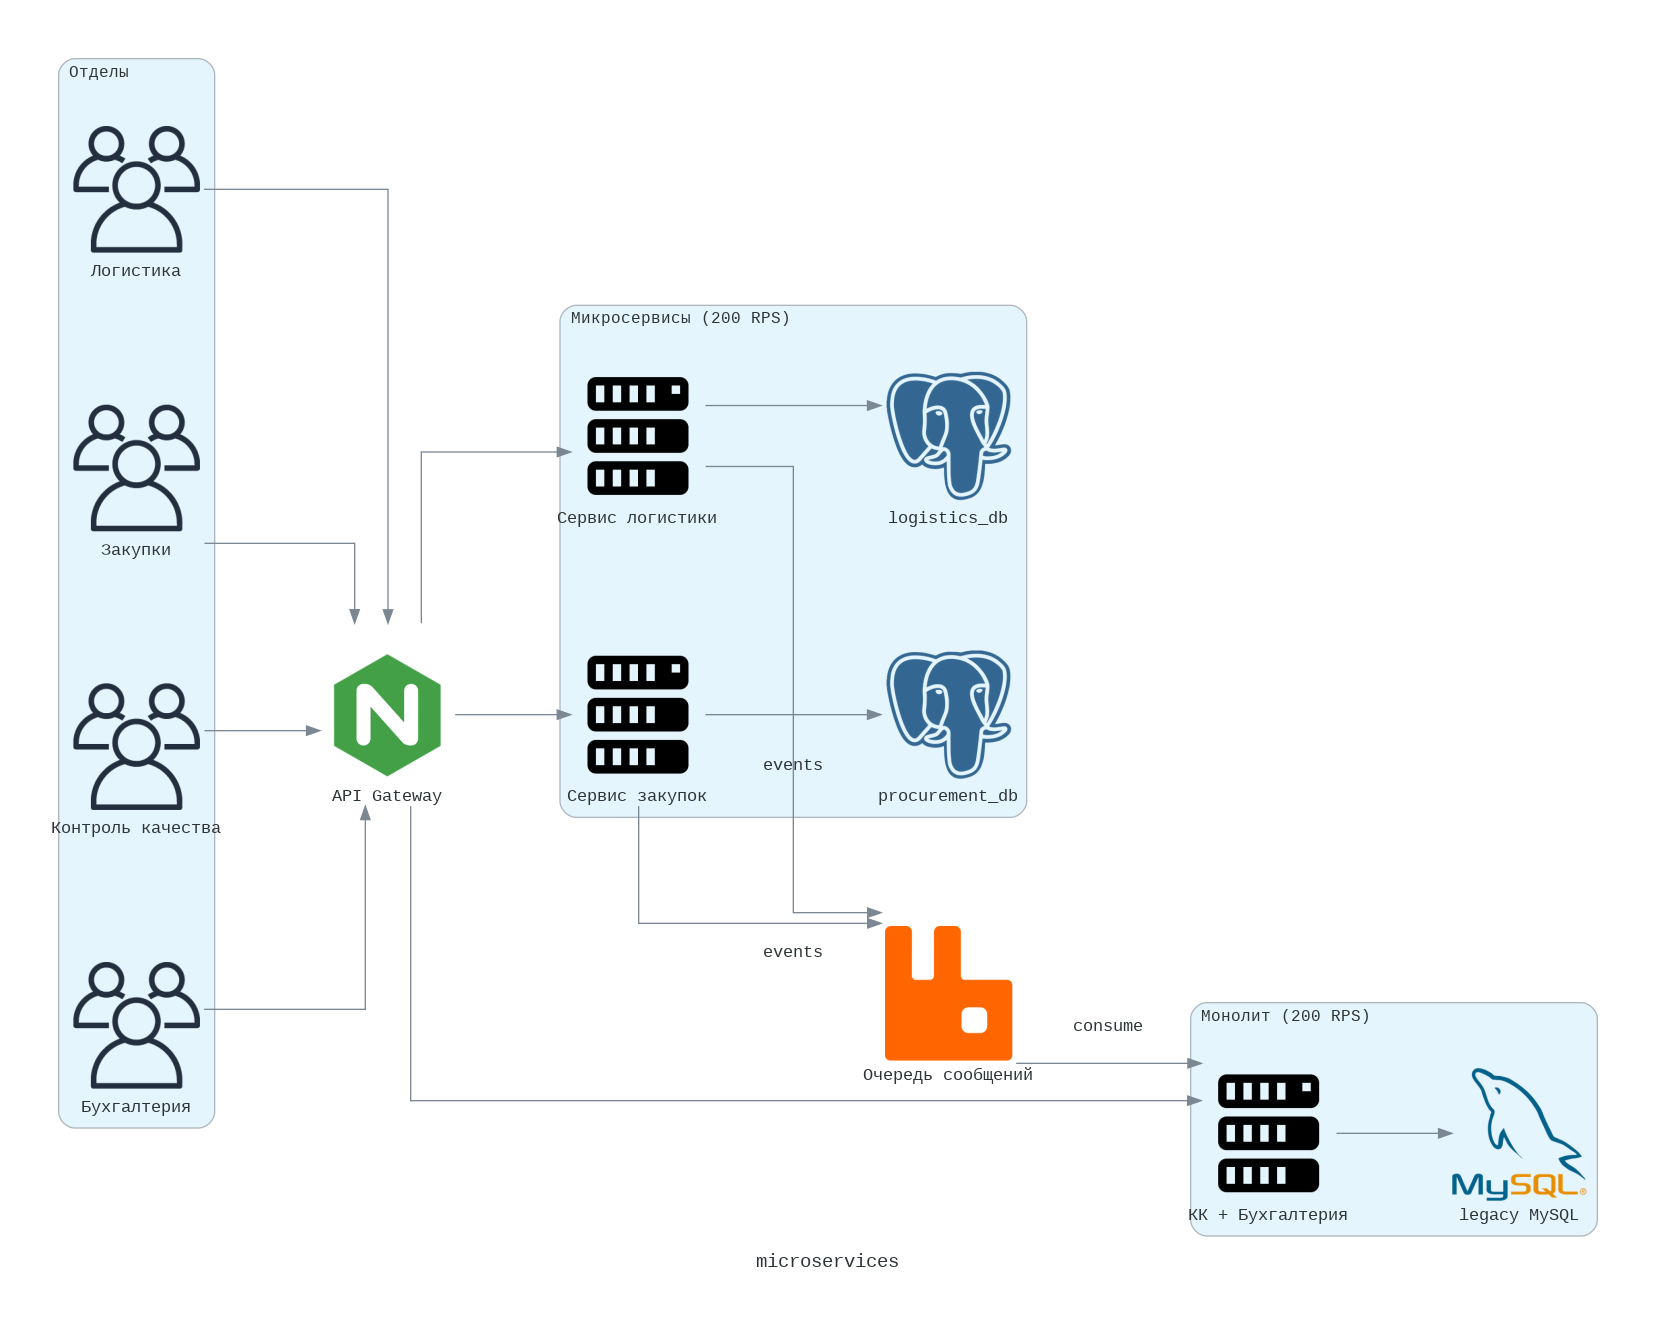

In [ ]:
from IPython.display import Image, display
!python microservices_diagram.py
display(Image(filename='/content/microservices.png'))

### Задание 3. Составить документацию взаимодействия сервисов, используя библиотеку docker-compose-diagram

Изучите нотацию библиотеки [Diagrams](https://diagrams.mingrammer.com/docs/nodes/onprem) для указания изображений узлов.

Изучите библиотеку [docker-compose-diagram](https://github.com/skonik/docker-compose-diagram) для документирования докер-компоуз-файлов с помощью лейблов.

Создайте диаграмму простого взаимодействия сервисов (веб-сервер и база данных) добавляя лейблы, чтобы получилось примерно как изображено на рисунке.

%%html

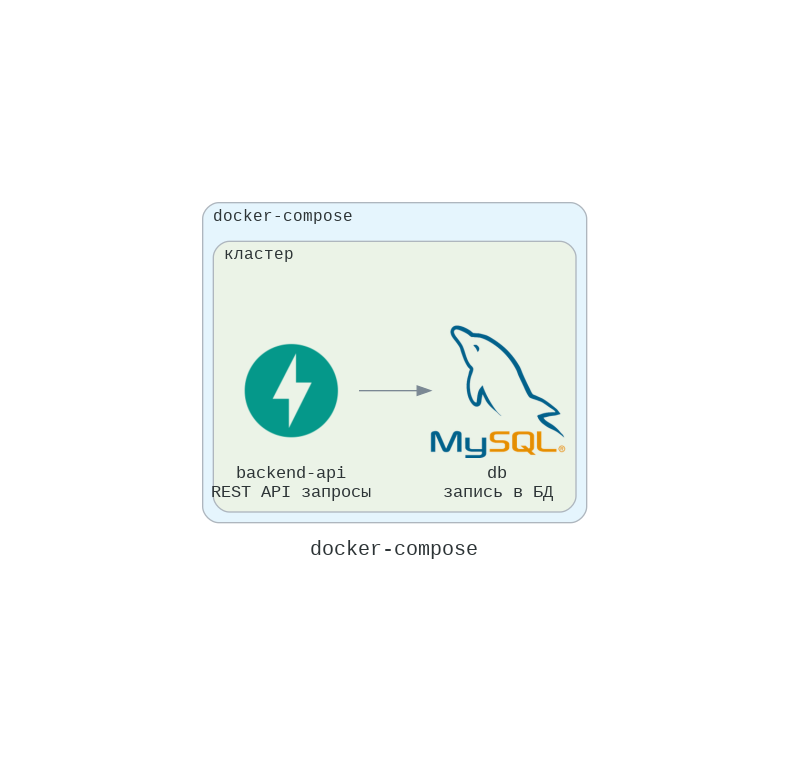

In [ ]:
%%writefile docker-compose.yml
services:

  backend-api:
    build:
      context: ..
      dockerfile: docker/django/Dockerfile
    image: dev_backend
    container_name: dev_backend
    restart: always
    volumes:
      - ..:/app/
    depends_on:
      - db
    working_dir: "/app/backend"
    expose:
      - 8000
    ports:
      - "8000:8000"
    command: runserver
    labels:
      "docker_compose_diagram.icon": "diagrams.programming.framework.Django"
      "docker_compose_diagram.cluster": "Application"
      "docker_compose_diagram.description": "Django API :8000"

  db:
    container_name: backend_api_db
    image: mysql/mysql-server:8
    volumes:
      - mysql_data:/var/lib/mysql
    restart: unless-stopped
    ports:
      - "3306:3306"
    labels:
      "docker_compose_diagram.icon": "diagrams.onprem.database.MySQL"
      "docker_compose_diagram.cluster": "Database"
      "docker_compose_diagram.description": "MySQL 8 :3306"

volumes:
  mysql_data:

Overwriting docker-compose.yml


In [ ]:
!compose-diagram --file docker-compose.yml --direction=LR --nodesep=1.5

File docker-compose.yml has been found. Reading! 📗 
Service: backend-api
   Service: {'docker_compose_diagram.icon': 
'diagrams.programming.framework.Django', 'docker_compose_diagram.cluster': 
'Application', 'docker_compose_diagram.description': 'Django API :8000'}
Service: db
   Service: {'docker_compose_diagram.icon': 'diagrams.onprem.database.MySQL', 
'docker_compose_diagram.cluster': 'Database', 
'docker_compose_diagram.description': 'MySQL 8 :3306'}
Your diagram has been saved in docker-compose.png 🖼️
⠙ Working..


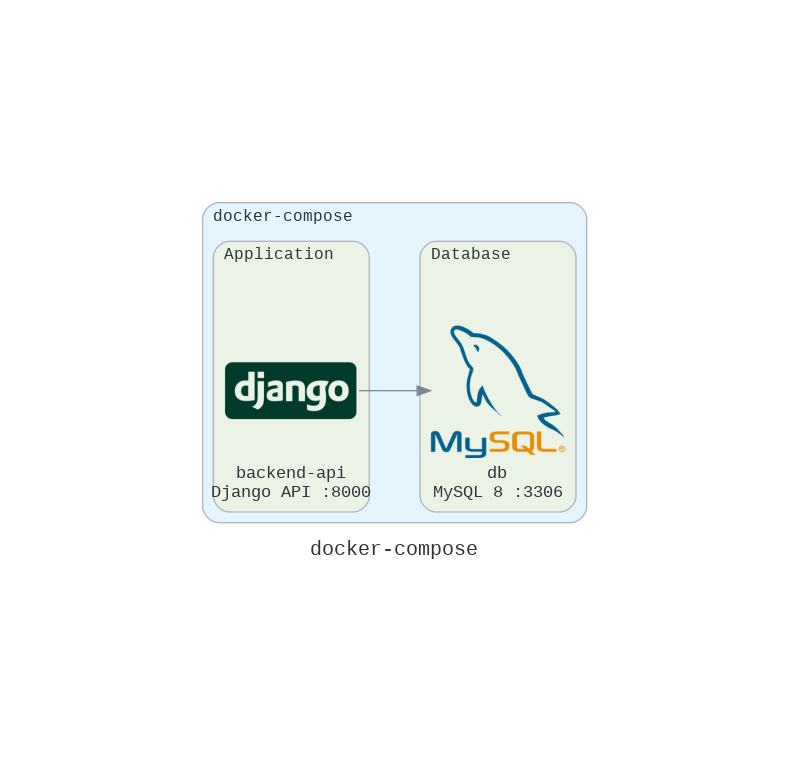

In [ ]:
image_path = '/content/docker-compose.png'
display(Image(filename=image_path))

Диаграмма выше сгенерирована из docker-compose.yml библиотекой docker-compose-diagram. Связь backend-api → db построена автоматически по полю depends_on — рисовать стрелки вручную не нужно. Лейблы задают иконку (полный путь класса из библиотеки diagrams, например diagrams.programming.framework.Django), кластер для группировки и описание узла.

С docker-compose-diagram не сразу разобрался, документации мало — пришлось смотреть исходники на GitHub, чтобы понять какие строки принимает поле icon. Полная микросервисная архитектура из задания 2 отрисована выше через библиотеку Diagrams (ячейки с diagram.py и microservices_diagram.py), а здесь показан базовый пример: веб-сервер + база данных с лейблами, как требуется в задании.

### Задание 4. Выбрать подходящие паттерны интеграции сервисов (REST/gRPC/брокеры)

Есть монолитное веб-приложение с пропускной способностью ≈200 RPS, при росте нагрузки до ≈400 RPS начинает ощущаться деградация.

Предложите 3 гипотезы, основываясь на [HDD-подходе](https://colab.research.google.com/drive/1vzl2jhLMJuLN-ZcYiPiIeJ7ribHMGDwt?usp=sharing) и исходя из вводных данных:

## REST (будет выдавать 1000 RPS)
* DevCost = 120000 — зарплата разработчиков.
* InfraCost =  50000 — стоимость инфраструктуры.
* featureEstimate = 85 — оценка фичи в стори-поинтах.
* ReworkRate =  0.2; процент доработок/исправлений — от 0.0 до 1.0.

## gRPC (будет выдавать 10000 RPS)

* DevCost = 1000000 — зарплата разработчиков.
* InfraCost =  500000 — стоимость инфраструктуры.
* featureEstimate = 850 — оценка фичи в стори-поинтах.
* ReworkRate =  0.4; процент доработок/исправлений — от 0.0 до 1.0.

## брокеры (будет выдавать 1000000 RPS)

* DevCost = 1200000 — зарплата разработчиков.
* InfraCost =  1500000 — стоимость инфраструктуры.
* featureEstimate = 8500 — оценка фичи в стори-поинтах.
* ReworkRate =  0.6; процент доработок/исправлений — от 0.0 до 1.0.

In [ ]:
import pandas as pd

# Исходные данные из задания
hypotheses = {
    'REST': {
        'DevCost': 120_000, 'InfraCost': 50_000,
        'featureEstimate': 85, 'ReworkRate': 0.2, 'RPS': 1_000
    },
    'gRPC': {
        'DevCost': 1_000_000, 'InfraCost': 500_000,
        'featureEstimate': 850, 'ReworkRate': 0.4, 'RPS': 10_000
    },
    'Брокеры': {
        'DevCost': 1_200_000, 'InfraCost': 1_500_000,
        'featureEstimate': 8_500, 'ReworkRate': 0.6, 'RPS': 1_000_000
    }
}

target_rps = 400  # текущая потребность
rows = []

for name, h in hypotheses.items():
    total = h['DevCost'] + h['InfraCost']
    adjusted = total * (1 + h['ReworkRate'])  # с учётом доработок
    effort = h['featureEstimate'] * (1 + h['ReworkRate'])
    rows.append({
        'Гипотеза': name,
        'DevCost': h['DevCost'],
        'InfraCost': h['InfraCost'],
        'TotalCost': total,
        'ReworkRate': h['ReworkRate'],
        'AdjustedCost': adjusted,
        'Effort (SP)': effort,
        'RPS': h['RPS'],
        'Запас (x)': f"{h['RPS'] / target_rps:.1f}x",
        'Cost/RPS': round(adjusted / h['RPS'], 2)
    })

df = pd.DataFrame(rows).set_index('Гипотеза')
display(df)

print(f"\nЦелевой RPS: {target_rps}")
print(f"REST: {rows[0]['AdjustedCost']:,.0f} за {rows[0]['RPS']:,} RPS (запас {rows[0]['RPS']/target_rps:.1f}x)")
print(f"gRPC: {rows[1]['AdjustedCost']:,.0f} за {rows[1]['RPS']:,} RPS — в {rows[1]['AdjustedCost']/rows[0]['AdjustedCost']:.1f}x дороже REST")
print(f"Брокеры: {rows[2]['AdjustedCost']:,.0f} за {rows[2]['RPS']:,} RPS — в {rows[2]['AdjustedCost']/rows[0]['AdjustedCost']:.1f}x дороже REST")

,DevCost,InfraCost,TotalCost,ReworkRate,AdjustedCost,Effort (SP),RPS,Запас (x),Cost/RPS
Гипотеза,,,,,,,,,
REST,120000,50000,170000,0.2,204000.0,102.0,1000,2.5x,204.00
gRPC,1000000,500000,1500000,0.4,2100000.0,1190.0,10000,25.0x,210.00
Брокеры,1200000,1500000,2700000,0.6,4320000.0,13600.0,1000000,2500.0x,4.32



Целевой RPS: 400
REST: 204,000 за 1,000 RPS (запас 2.5x)
gRPC: 2,100,000 за 10,000 RPS — в 10.3x дороже REST
Брокеры: 4,320,000 за 1,000,000 RPS — в 21.2x дороже REST


По HDD-расчёту видно, что REST - оптимальный выбор для кейса с 400 RPS. Стоимость с учётом доработок - 204K, при этом запас производительности 2.5x. gRPC обойдётся в 2.1M (в 10 раз дороже), а брокеры - в 4.3M (в 21 раз дороже). ReworkRate у REST - 20% (технология знакома команде), у gRPC - 40%, у брокеров - 60%. Закономерность: чем сложнее стек, тем больше доработок.

Но мне кажется, в реальности это не или-или, а комбинация. На конкретных связках из задания 2:

**Гипотеза 1 (REST):** Для синхронных запросов API Gateway → сервисы (каталог логистики, список закупок) REST - очевидный выбор. Простой, понятный, JSON. Фронтенд и мобильные клиенты ожидают REST. Стоимость за 1 RPS - 204 руб., это на порядок дешевле альтернатив.

**Гипотеза 2 (gRPC):** Для внутренних вызовов между микросервисами (сервис логистики → сервис закупок для проверки наличия товара) gRPC даёт выигрыш по размеру payload (protobuf vs JSON) и строгую типизацию через proto-файлы. Но при 400 RPS этот выигрыш не оправдывает 10-кратное увеличение стоимости. Выбор между REST и gRPC для внутренних вызовов был не очевиден, пока не прикинул разницу - на наших объёмах protobuf не даст значимого ускорения.

**Гипотеза 3 (Брокеры):** Для асинхронных событий (оплата перевозки → уведомление бухгалтерии, логистика → аналитика) брокер сообщений необходим. Но не для всех коммуникаций, а только для fire-and-forget и event-driven сценариев. Использовать брокер вместо синхронных запросов - оверинжиниринг.

**Рекомендация:** REST как основной протокол (90% вызовов), RabbitMQ для асинхронных событий между сервисами (10% вызовов). gRPC оставляем на будущее - если нагрузка вырастет до 5000+ RPS и размер JSON-payload станет узким местом.

### Задание 5. Разработать схему ML-системы для обработки табличных данных

**Писать код не нужно.**

Нужно составить список вопросов, без которых невозможно начать разработку ML-системы, выбрать архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

**Вводные данные от бизнеса: «Как привлечь клиентов на депозит?» и результат прошлой маркетинговой кампании.**

In [ ]:
!pip install scikit-learn -qqq
from sklearn.datasets import fetch_openml
X, y = fetch_openml("bank-marketing", version=1, as_frame=True, return_X_y=True)
display(X.merge(y,left_index=True,right_index=True).tail())
y.value_counts() #<-внес ли клиент срочный депозит по итогам маркетинговой компании? ("да = 2"/"нет = 1")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,2
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,2
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,2
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,1
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,1


,count
Class,
1,39922
2,5289


**Вопросы, без которых нельзя начинать разработку ML-системы:**

Прежде чем рисовать архитектуру, мне нужно понять требования бизнеса. Бизнес спрашивает «как привлечь клиентов на депозит?» - но это слишком размыто для инженера. Вот что я бы уточнил:

1. **Режим предсказаний** - real-time API или batch-скоринг? Если маркетологам нужен список клиентов для обзвона раз в неделю, хватит batch. Если нужно показывать персональное предложение на сайте банка в момент визита - нужен API с latency < 100ms.

2. **Частота переобучения** - как часто обновляются данные о клиентах? Если кампании раз в квартал, модель можно переобучать вручную. Если поток непрерывный - нужен автоматический retraining pipeline.

3. **Метрики качества** - что важнее: recall (не пропустить потенциального вкладчика) или precision (не тратить время менеджера на нецелевых клиентов)? Это определит порог классификации и выбор алгоритма.

4. **Объём данных** - dataset bank-marketing: ~45K строк, 16 признаков. Scikit-learn справится, тяжёлые фреймворки (Spark, GPU) не нужны.

5. **Интерпретируемость** - банковский домен, возможны регуляторные требования объяснять решения модели. Это ограничивает выбор: logistic regression или gradient boosting + SHAP для интерпретации.

6. **Data privacy** - персональные данные клиентов, нужна анонимизация и контроль доступа к данным.

7. **Обратная связь** - как узнаем, что модель работает в проде? Нужен мониторинг data drift и tracking конверсии по предсказаниям.

**Архитектура ML-пайплайна:**

ML-схему я рисовал по аналогии с тем, как у нас на работе устроен ETL - только добавил serving-слой и мониторинг drift. Пайплайн состоит из пяти сервисов:

- **Ingestion Service** - забирает данные из CRM банка, складывает в PostgreSQL. По аналогии с моим рабочим ETL, только там cron + Python-скрипт, а для production лучше оркестратор.
- **Preprocessing Service** - feature engineering: encoding категориальных переменных, нормализация, создание новых признаков. Результат кешируется в Redis для быстрого доступа при inference.
- **Training Service** - обучение модели. Для 45K строк табличных данных - scikit-learn + LightGBM/CatBoost. Модель сохраняется в Model Registry с версионированием.
- **Serving Service** - FastAPI-эндпоинт (тут мой пет-проект пригодился как опыт), принимает признаки клиента, возвращает вероятность подписки на депозит.
- **Monitoring** - Prometheus собирает метрики (latency, throughput, распределение предсказаний), Grafana визуализирует. Алерт если распределение сдвинулось (data drift).

In [ ]:
%%writefile /content/ml_pipeline.py
from diagrams import Cluster, Diagram, Edge
from diagrams.onprem.compute import Server
from diagrams.onprem.database import PostgreSQL
from diagrams.onprem.queue import Kafka
from diagrams.onprem.monitoring import Grafana, Prometheus
from diagrams.onprem.inmemory import Redis
from diagrams.programming.flowchart import Action

with Diagram("ml_pipeline", show=False, direction="LR"):

    data_source = PostgreSQL("Bank CRM\n(raw data)")

    with Cluster("Data Pipeline"):
        ingestion = Server("Ingestion\nService")
        preprocessing = Server("Preprocessing\n(feature eng.)")

    with Cluster("ML Training"):
        training = Server("Training\nService")
        registry = Action("Model\nRegistry")

    with Cluster("Serving"):
        api = Server("Prediction API\n(FastAPI)")
        cache = Redis("Feature\nCache")

    with Cluster("Monitoring"):
        prom = Prometheus("Metrics")
        graf = Grafana("Dashboard\n(drift alert)")

    data_source >> Edge(label="raw data") >> ingestion
    ingestion >> preprocessing
    preprocessing >> Edge(label="features") >> training
    training >> Edge(label="model v.N") >> registry
    registry >> api
    cache >> api
    preprocessing >> Edge(label="cache") >> cache
    api >> Edge(label="predictions") >> prom
    prom >> graf

Overwriting /content/ml_pipeline.py


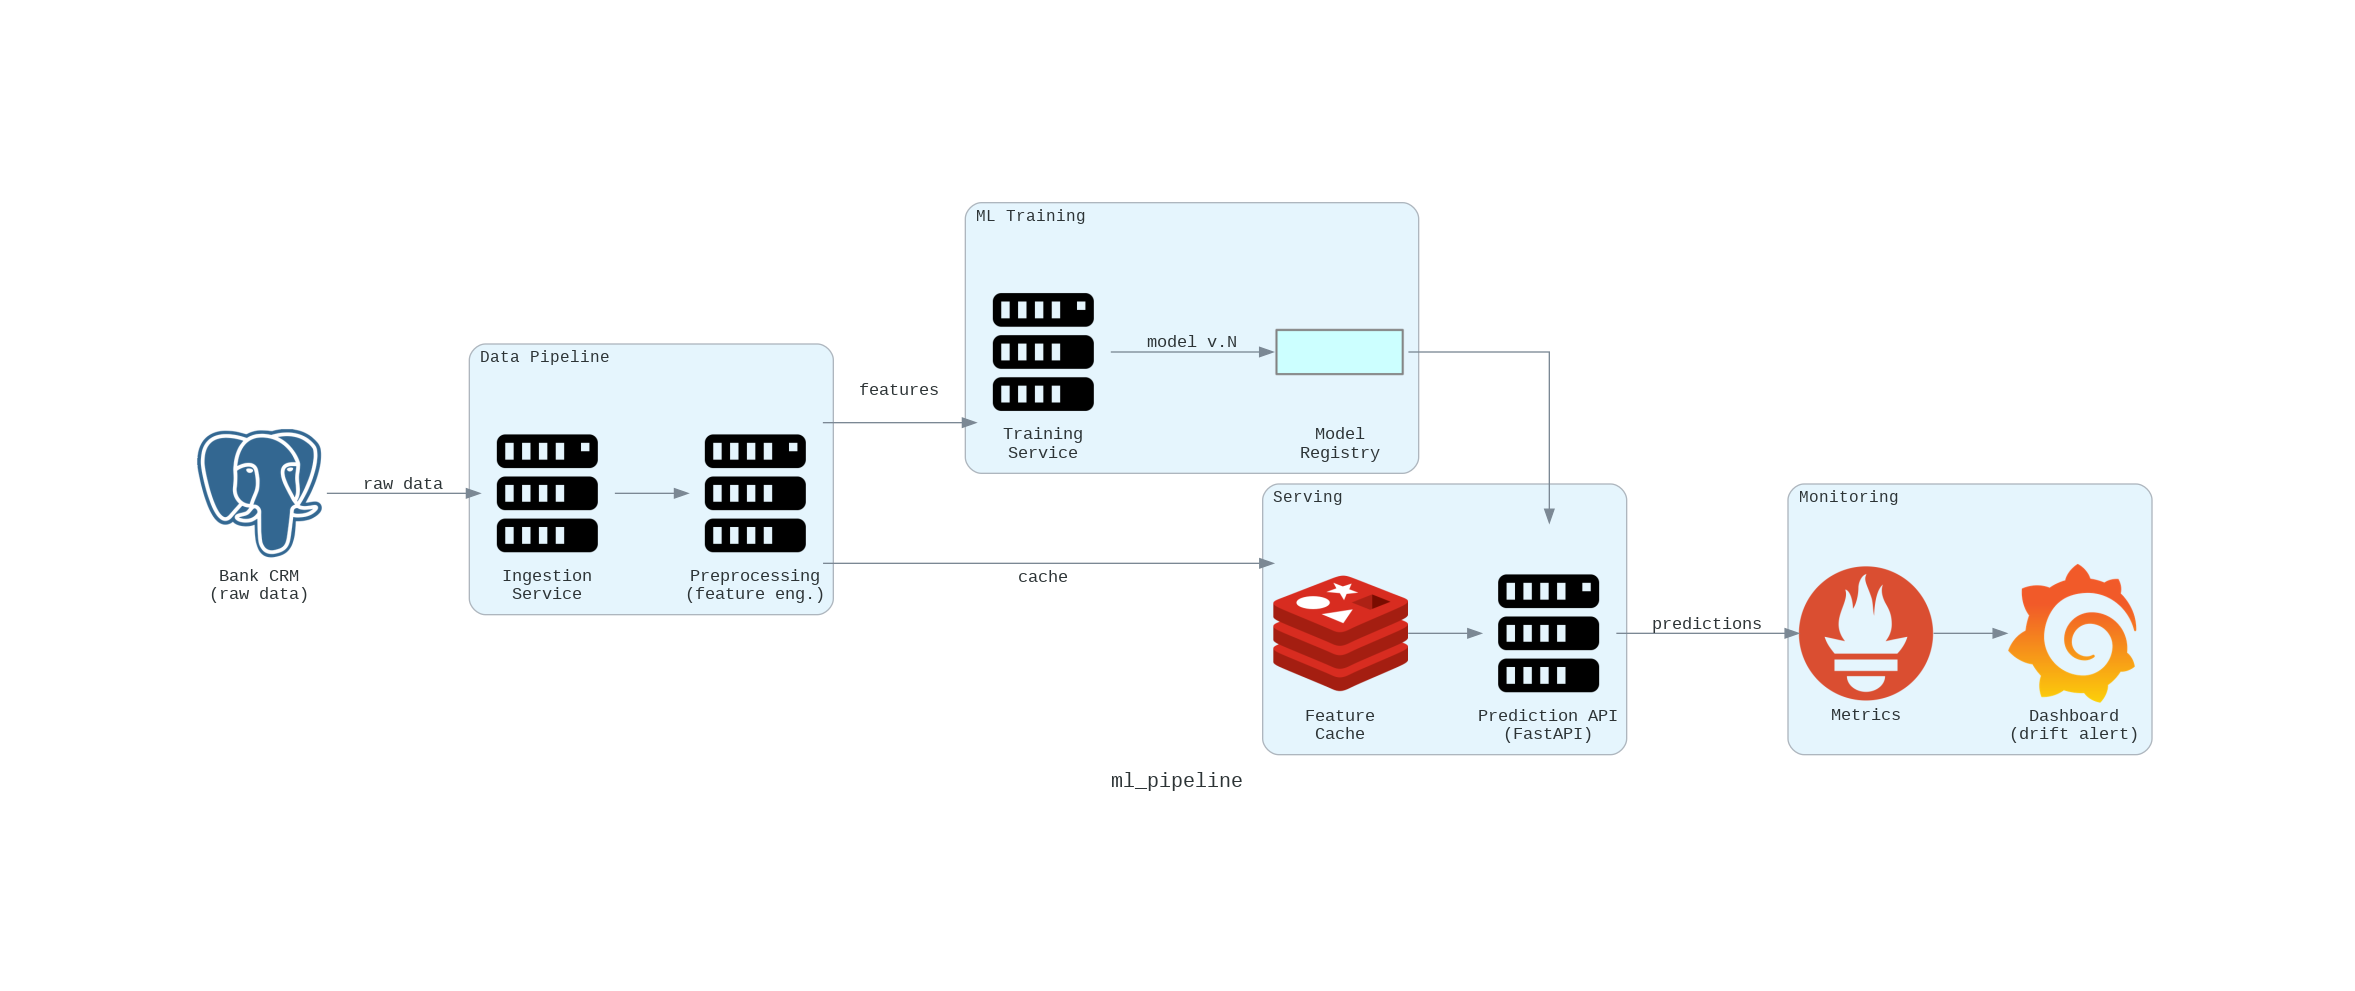

In [ ]:
from IPython.display import Image, display
!python ml_pipeline.py
display(Image(filename='/content/ml_pipeline.png'))

## Итоговое оформление

1. Сформулируйте ниже 5–8 выводов, когда стоит разбивать монолит на микросервисы.
2. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита.
3. Запустите блокнот, чтобы получить диаграмму простого взаимодействия сервисов (веб-сервер и база данных), используя лейблы.
4. Обоснуйте в 5–8 предложениях выбранный паттерн интеграции сервисов.
5. Без чего немыслимо начинать разработку ML-системы?
6. Проверьте, что ноутбук запускается.  

### Мои выводы

**Когда разбивать монолит:**

1. Команды блокируют друг друга на деплое - мерж-конфликты, длинные релизные циклы.
2. Неравномерная нагрузка на модули - один сервис надо масштабировать, остальные простаивают (как в нашем кейсе: 400 vs 200 RPS).
3. Нужна технологическая гибкость - разные языки и фреймворки для разных задач.
4. Требуется fault isolation - отказ одного модуля не должен ронять всю систему.
5. Границы доменов чёткие - bounded contexts хорошо выражены, разделение будет естественным.
6. Не разбивать, если команда маленькая, домены не определились, или нет реальных проблем с нагрузкой - иначе получится distributed monolith.

**Подход к декомпозиции:**

Начинаю с доменного анализа - определяю bounded contexts по бизнес-процессам и данным. Приоритизирую вынесение по нагрузке: первыми уходят сервисы, генерирующие больше всего RPS. Strangler Fig Pattern для постепенной миграции - ставлю API Gateway и перенаправляю трафик маршрут за маршрутом. Каждый сервис получает свою базу данных, согласованность - eventual consistency через события в очередь.

**Паттерны интеграции:**

HDD-расчёт подтвердил: REST - оптимален для 400 RPS при минимальной стоимости (204K с учётом доработок). Брокер нужен только для async-событий. gRPC - запас на будущее при росте нагрузки.

**ML-система:**

Главный урок - не бросаться сразу писать модель, а задать правильные вопросы бизнесу. Режим предсказаний, метрики, интерпретируемость, privacy - всё это определяет архитектуру ещё до первой строки кода. Для табличных данных на 45K строк тяжёлая инфраструктура не нужна - scikit-learn + FastAPI + мониторинг.

**Рефлексия:**

Честно говоря, сначала думал что микросервисы - это просто разрежь монолит на куски, но на практике 90% сложности - в межсервисном взаимодействии, согласованности данных и операционном overhead. Мне как DBA особенно понятна боль с distributed transactions - ACID в рамках одной базы и eventual consistency через брокер - это совсем разные уровни сложности. С docker-compose-diagram пришлось повозиться, документации минимум. Выбор между REST и gRPC для внутренних вызовов был не очевиден, пока не прикинул разницу в размере payload на protobuf vs JSON - на наших объёмах это не существенно.